In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style('darkgrid')
sns.set_palette('viridis')

print("All libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

All libraries imported successfully!
NumPy version: 2.4.6
Pandas version: 3.0.3
Seaborn version: 0.13.2


In [2]:
# Load iris dataset — built into seaborn just like tips!
df = sns.load_dataset('iris')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (150, 5)


Module 4 — Relationship Analysis

The question we're asking:

In Module 3 we looked at one measurement at a time — just petal_length, just sepal_width etc.

In Module 4 we look at two measurements together — does petal_length and petal_width together tell us more than each one alone?


Real life analogy:

Imagine you're trying to identify a person:

Height alone → not enough, many people are 6ft

Weight alone → not enough, many people are 180lbs

Height AND weight together → much better picture!

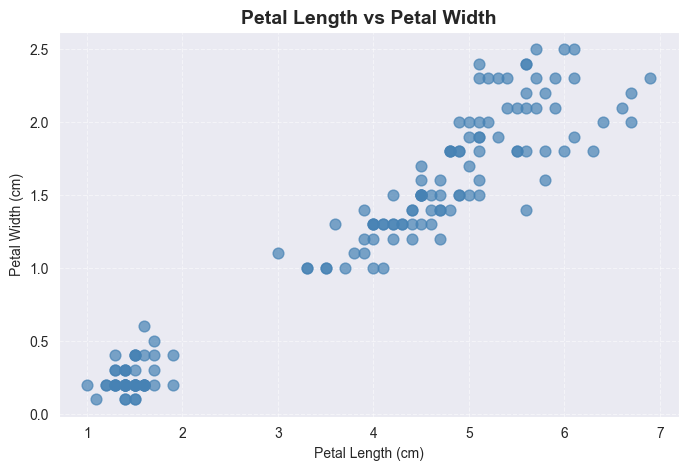

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['petal_length'], df['petal_width'],
           alpha=0.7, color='steelblue', s=60)

ax.set_title('Petal Length vs Petal Width', fontsize=14, fontweight='bold')
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.grid(linestyle='--', alpha=0.5)

plt.show()

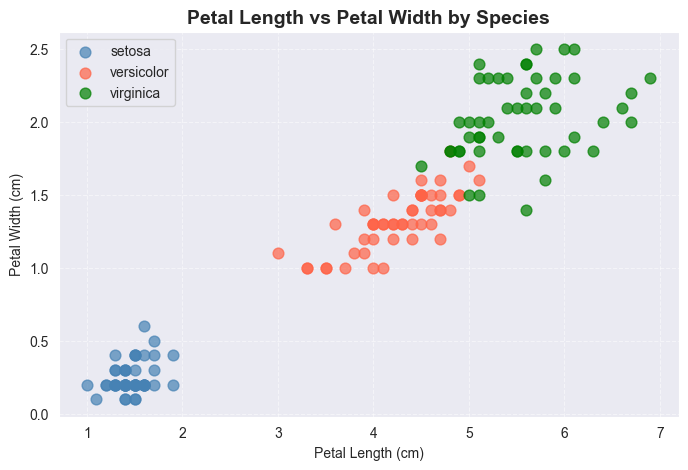

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'setosa': 'steelblue', 'versicolor': 'tomato', 'virginica': 'green'}

for species, group in df.groupby('species'):
    ax.scatter(group['petal_length'], group['petal_width'],
               label=species,
               color=colors[species],
               alpha=0.7, s=60)

ax.set_title('Petal Length vs Petal Width by Species', fontsize=14, fontweight='bold')
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.legend()
ax.grid(linestyle='--', alpha=0.5)

plt.show()

Cell 3 — Pair plot — the most powerful Seaborn chart:

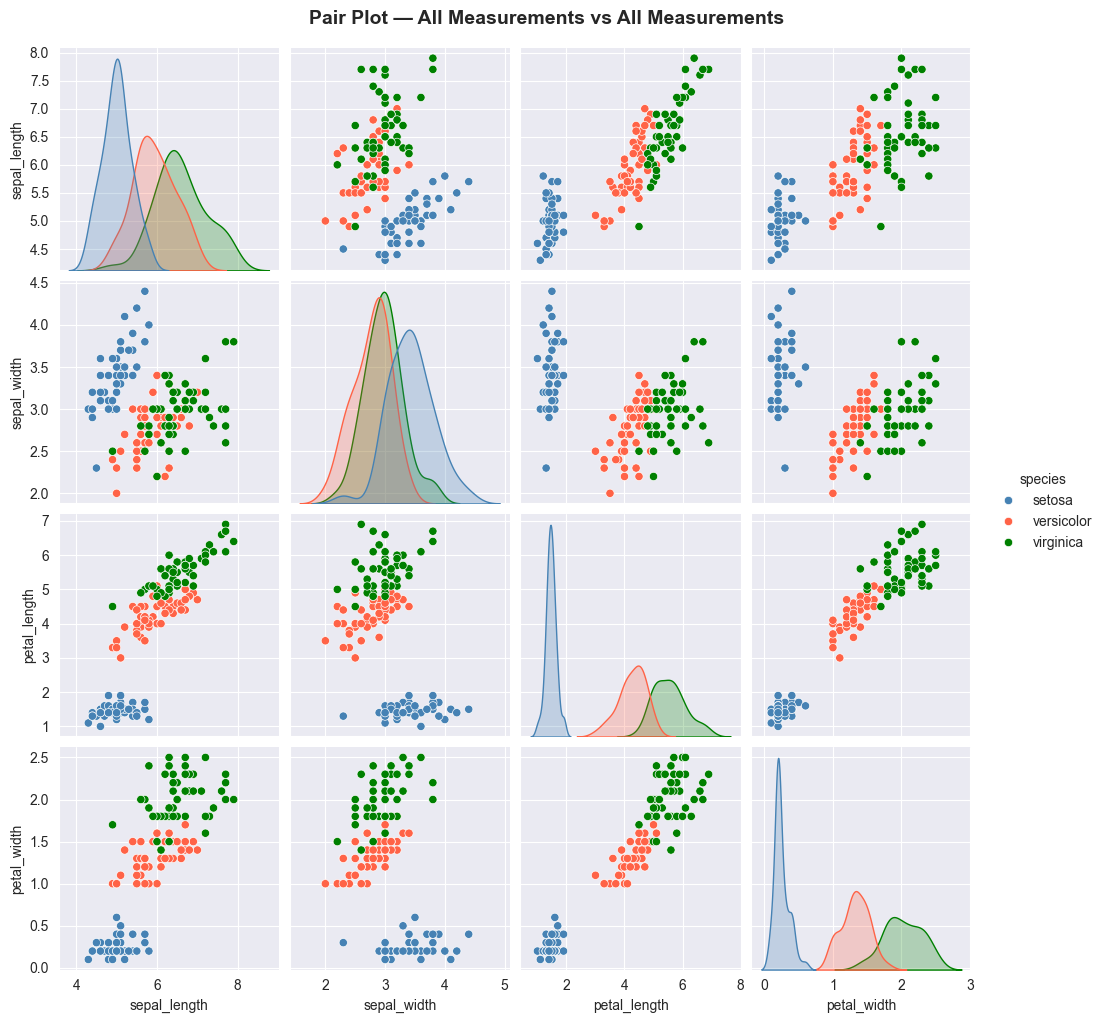

In [5]:
sns.pairplot(df, hue='species', 
             palette={'setosa': 'steelblue', 
                      'versicolor': 'tomato', 
                      'virginica': 'green'})

plt.suptitle('Pair Plot — All Measurements vs All Measurements', 
             y=1.02, fontsize=14, fontweight='bold')

plt.show()

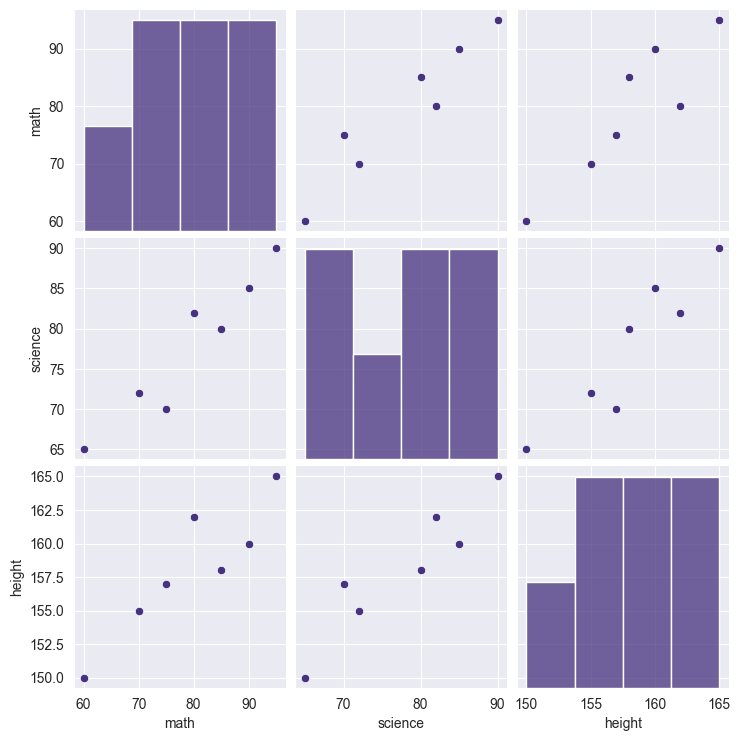

In [6]:
import pandas as pd
import seaborn as sns

# Simple 3 column dataset
simple_data = pd.DataFrame({
    'math':    [90, 70, 85, 60, 95, 75, 80],
    'science': [85, 72, 80, 65, 90, 70, 82],
    'height':  [160, 155, 158, 150, 165, 157, 162]
})

sns.pairplot(simple_data)
plt.show()

Cell 4 — Correlation Heatmap

              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00        -0.12          0.87         0.82
sepal_width          -0.12         1.00         -0.43        -0.37
petal_length          0.87        -0.43          1.00         0.96
petal_width           0.82        -0.37          0.96         1.00


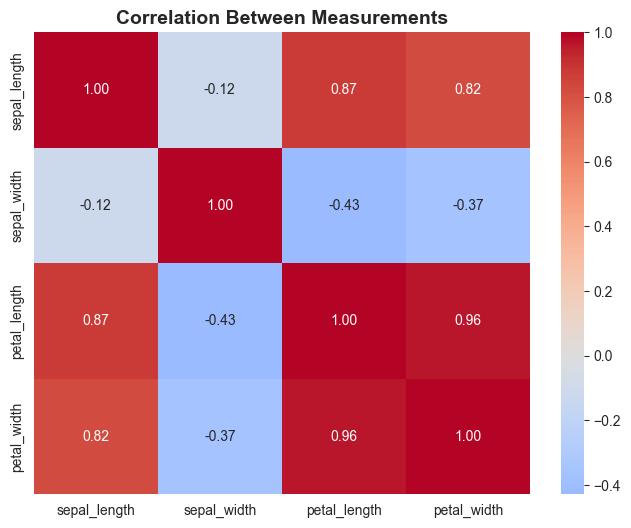

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate correlation between all measurements
correlation = df.drop('species', axis=1).corr()
print(correlation.round(2))

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=ax)

ax.set_title('Correlation Between Measurements', fontsize=14, fontweight='bold')
plt.show()